# Day 5 — Model Explainability & Prototype Deployment

**Objective**
- Generate global and patient-level explainability using **SHAP** and **LIME**
- Validate interpretability outputs for **clinical relevance**
- Package the selected model (**XGBoost**) into a **Gradio** prototype for dosing recommendations

**Target**
- `Final_Stable_Dose_mg`

**Note on reproducibility**
- We set a global seed and rebuild the model using the same hyperparameters logged in MLflow.
- We avoid loading artifacts from MLflow to prevent file-path / Git-LFS / pickle issues.

In [1]:
# ==============================
# Imports (Day 5)
# ==============================

import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

import shap
from lime.lime_tabular import LimeTabularExplainer

# ==============================
# Reproducibility
# ==============================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Output folder for explainability artifacts
ARTIFACT_DIR = Path("artifacts/day5_explainability")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Imports done. Artifacts will be saved to:", ARTIFACT_DIR.resolve())

C:\Users\caspe\anaconda\envs\genexa_ds\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports done. Artifacts will be saved to: C:\Users\caspe\OneDrive\Documents\genexahealth\genexahealth-data\notebooks\artifacts\day5_explainability


In [2]:
# ==============================
# Load engineered dataset (ROBUST PATH)
# ==============================

from pathlib import Path
import pandas as pd

# Get project root (one level above /notebooks)
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "merged_patient_dataset_engineered.csv"

print("Looking for dataset at:")
print(DATA_PATH.resolve())

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

print("✅ Dataset loaded successfully")
print("Shape:", df.shape)
df.head(2)

Looking for dataset at:
C:\Users\caspe\OneDrive\Documents\genexahealth\genexahealth-data\data\processed\merged_patient_dataset_engineered.csv
✅ Dataset loaded successfully
Shape: (50000, 31)


,patient_id,CYP2C9,VKORC1,CYP4F2,Age,Sex,Weight_kg,Height_cm,Ethnicity,Hypertension,...,INR_Stabilization_Days,Adverse_Event,Time_in_Therapeutic_Range_Pct,Adverse_Event_Flag,CYP2C9_risk,VKORC1_sensitivity,CYP4F2_effect,BMI,Amiodarone_CYP2C9_interaction,Comorbidity_Score
0,P000001,*1/*3,A/G,C/C,64,F,88,194,Caucasian,0,...,5,NaN,66.8,0,1,1,0,23.381868,0,0
1,P000002,*1/*1,A/G,C/C,50,M,101,175,Other,1,...,8,NaN,72.4,0,0,1,0,32.979592,0,1


## Step 2 — Define target and features

We will predict **Final_Stable_Dose_mg** (final stable warfarin dose in mg).

We also remove any obvious identifier columns (if present) to prevent leakage and ensure the model learns from clinical/genetic/demographic predictors rather than IDs.

In [3]:
# ==============================
# Target / Features
# ==============================

TARGET_COL = "Final_Stable_Dose_mg"

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found. Available columns include: {list(df.columns)[:30]} ...")

# Drop target + any ID-like columns if present (prevents leakage)
drop_cols = [TARGET_COL]
possible_id_cols = ["patient_id", "id", "uuid", "Patient_ID", "patientID", "name", "full_name"]
drop_cols += [c for c in possible_id_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df[TARGET_COL].astype(float)

print("✅ X shape:", X.shape)
print("✅ y shape:", y.shape)
print("\nTarget summary:\n", y.describe())

✅ X shape: (50000, 29)
✅ y shape: (50000,)

Target summary:
 count    50000.000000
mean         3.294196
std          1.620941
min          1.000000
25%          2.000000
50%          3.000000
75%          4.400000
max         10.100000
Name: Final_Stable_Dose_mg, dtype: float64


## Step 3 — Train/Test split + preprocessing

We use an 80/20 split and build a preprocessing pipeline:
- **Numeric features** → standard scaling
- **Categorical features** → one-hot encoding (handles unseen categories safely)

In [4]:
# ==============================
# Train/Test split + preprocessing
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"Categorical cols: {len(cat_cols)} | Numeric cols: {len(num_cols)}")

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("scaler", StandardScaler())]), num_cols),
        ("cat", Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
    ],
    remainder="drop"
)

Categorical cols: 9 | Numeric cols: 20


## Step 4 — Rebuild the best model (XGBoost) using MLflow parameters

We rebuild XGBoost using the hyperparameters recorded in MLflow to ensure reproducibility.

In [5]:
# ==============================
# XGBoost (best model) + full pipeline
# ==============================

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

xgb = XGBRegressor(
    objective="reg:squarederror",
    colsample_bytree=0.85,
    learning_rate=0.03,
    max_depth=4,
    n_estimators=1500,
    subsample=0.85,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1
)

best_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", xgb)
])

print("✅ XGB pipeline created.")

✅ XGB pipeline created.


## Step 5 — Train and evaluate (holdout test)

We fit the pipeline on the training set and evaluate on the holdout test set using:
- RMSE
- MAE
- R²

In [6]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import json

best_pipe.fit(X_train, y_train)
pred = best_pipe.predict(X_test)

mse = mean_squared_error(y_test, pred)   # no squared= argument
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("✅ Holdout Test Metrics (XGB)")
print(f"RMSE: {rmse:.6f}")
print(f"MAE : {mae:.6f}")
print(f"R²  : {r2:.6f}")

metrics = {"rmse": float(rmse), "mae": float(mae), "r2": float(r2)}
with open(ARTIFACT_DIR / "day5_holdout_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("✅ Saved:", (ARTIFACT_DIR / "day5_holdout_metrics.json").resolve())

✅ Holdout Test Metrics (XGB)
RMSE: 0.547763
MAE : 0.396177
R²  : 0.885823
✅ Saved: C:\Users\caspe\OneDrive\Documents\genexahealth\genexahealth-data\notebooks\artifacts\day5_explainability\day5_holdout_metrics.json


## Step 6 — SHAP explainability (global + patient-level)

We generate:
- **Global** SHAP summary plot → top drivers of dose predictions across the test set
- **Patient-level** SHAP waterfall plot → explanation for a single patient prediction

C:\Users\caspe\AppData\Local\Temp\ipykernel_52624\2868911107.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_dense, feature_names=feature_names, show=False)


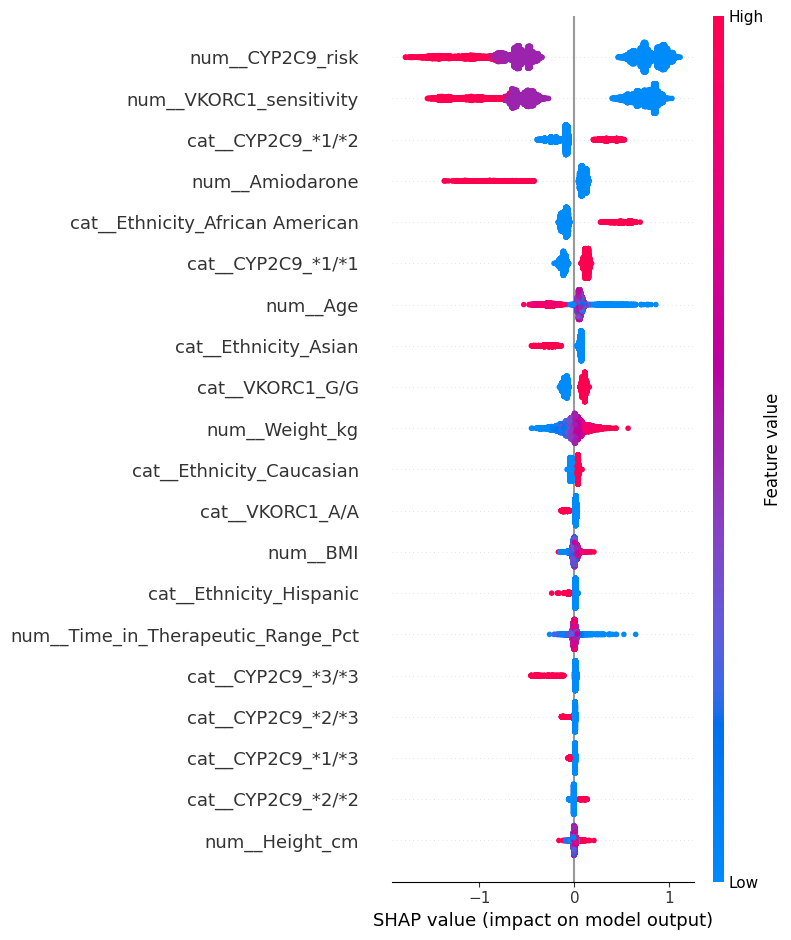

✅ Saved: C:\Users\caspe\OneDrive\Documents\genexahealth\genexahealth-data\notebooks\artifacts\day5_explainability\shap_global_summary.png


In [7]:
# ==============================
# SHAP global summary
# ==============================

import shap
import numpy as np
import matplotlib.pyplot as plt

prep = best_pipe.named_steps["prep"]
model = best_pipe.named_steps["model"]

X_test_t = prep.transform(X_test)
X_test_dense = X_test_t.toarray() if hasattr(X_test_t, "toarray") else X_test_t

feature_names = prep.get_feature_names_out()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_dense)

plt.figure()
shap.summary_plot(shap_values, X_test_dense, feature_names=feature_names, show=False)
plt.tight_layout()

out_path = ARTIFACT_DIR / "shap_global_summary.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("✅ Saved:", out_path.resolve())

Patient index: 0
Predicted dose: 0.994 mg
True dose     : 1.000 mg


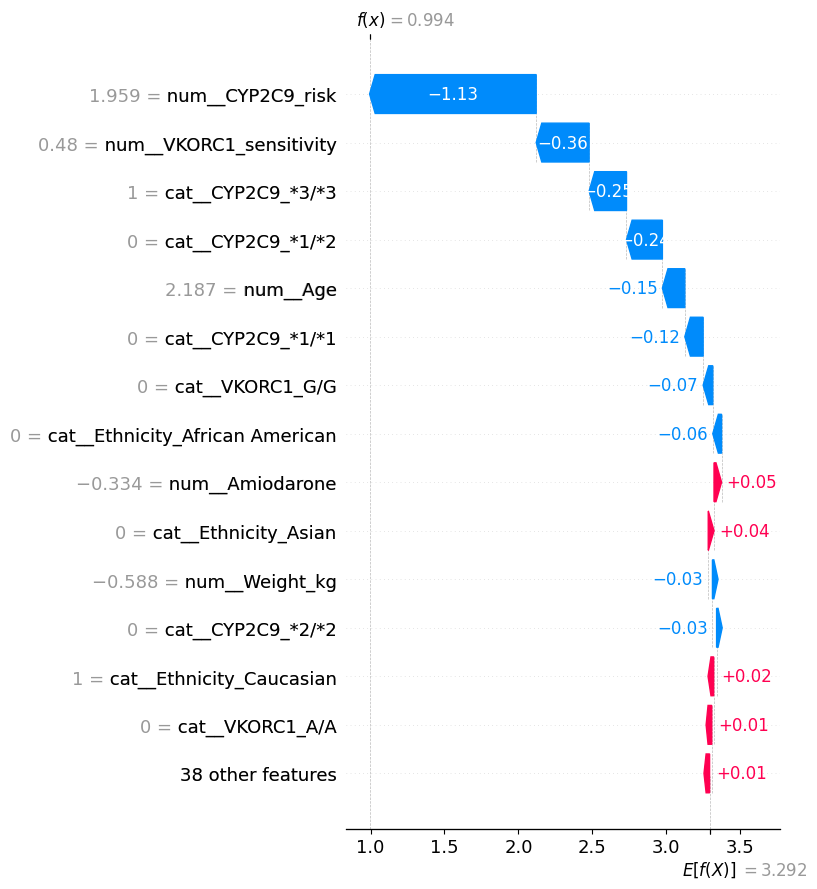

✅ Saved: C:\Users\caspe\OneDrive\Documents\genexahealth\genexahealth-data\notebooks\artifacts\day5_explainability\shap_patient_0_waterfall.png


In [8]:
# ==============================
# SHAP patient-level waterfall
# ==============================

patient_idx = 0  # change to any index within X_test

x_row = X_test.iloc[[patient_idx]]
x_row_t = prep.transform(x_row)
x_row_dense = x_row_t.toarray() if hasattr(x_row_t, "toarray") else x_row_t

pred_dose = float(best_pipe.predict(x_row)[0])
true_dose = float(y_test.iloc[patient_idx])

print(f"Patient index: {patient_idx}")
print(f"Predicted dose: {pred_dose:.3f} mg")
print(f"True dose     : {true_dose:.3f} mg")

exp = shap.Explanation(
    values=shap_values[patient_idx],
    base_values=explainer.expected_value,
    data=x_row_dense[0],
    feature_names=feature_names
)

plt.figure()
shap.plots.waterfall(exp, max_display=15, show=False)
plt.tight_layout()

out_path = ARTIFACT_DIR / f"shap_patient_{patient_idx}_waterfall.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print("✅ Saved:", out_path.resolve())

## Step 7 — LIME patient-level explainability

SHAP gives robust global + local explanations for tree models.
LIME complements this by fitting a simple local surrogate model around one patient and showing which features pushed the prediction up/down.

We will:
- use the *preprocessed* numeric matrix (after one-hot + scaling)
- explain a single test patient (`patient_idx`)
- save the explanation as an HTML file for easy viewing and sharing

In [9]:
from lime.lime_tabular import LimeTabularExplainer

# Reuse the same patient_idx you used for SHAP waterfall (change if you want)
patient_idx = 0

# Transform train/test using the SAME preprocessor
X_train_t = prep.transform(X_train)
X_test_t  = prep.transform(X_test)

# Convert sparse -> dense if needed (LIME expects dense arrays)
X_train_dense = X_train_t.toarray() if hasattr(X_train_t, "toarray") else X_train_t
X_test_dense  = X_test_t.toarray()  if hasattr(X_test_t, "toarray")  else X_test_t

# LIME predictor function (works on transformed arrays)
def predict_fn(arr_2d):
    return model.predict(arr_2d)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_dense,
    feature_names=list(feature_names),
    mode="regression",
    random_state=SEED,
    discretize_continuous=True
)

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_dense[patient_idx],
    predict_fn=predict_fn,
    num_features=15
)

lime_path = ARTIFACT_DIR / f"lime_patient_{patient_idx}.html"
lime_exp.save_to_file(str(lime_path))

print("✅ Saved LIME explanation:", lime_path.resolve())



✅ Saved LIME explanation: C:\Users\caspe\OneDrive\Documents\genexahealth\genexahealth-data\notebooks\artifacts\day5_explainability\lime_patient_0.html


## Step 8 — Clinical interpretability validation

We do three quick checks:

1) **Genetic plausibility:** CYP2C9 and VKORC1 should appear among top global drivers (expected).
2) **No leakage:** no patient IDs or obvious identifiers should show up as top features.
3) **Directionality check (sanity):** For a patient, the strongest features should move the prediction in a clinically interpretable way
   (e.g., genotype risk/sensitivity and interacting drugs like amiodarone can influence required dose).

Next we print:
- Top 20 global features from mean absolute SHAP
- A basic leakage scan for suspicious terms (id, patient, uuid, name)

In [10]:
import numpy as np

mean_abs = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs)[::-1][:20]
top_feats = [(feature_names[i], float(mean_abs[i])) for i in top_idx]

print("Top 20 global features by mean(|SHAP|):")
for f, v in top_feats:
    print(f" - {f:40s}  {v:.6f}")

leak_terms = ["id", "patient", "uuid", "name"]
leak_hits = [f for f, _ in top_feats if any(t in f.lower() for t in leak_terms)]

print("\nLeakage scan:", "✅ None found" if not leak_hits else f"⚠️ Possible leakage: {leak_hits}")

# Save for report/GitHub
txt_path = ARTIFACT_DIR / "interpretability_checks.txt"
with open(txt_path, "w", encoding="utf-8") as f:
    f.write("Top 20 global features by mean(|SHAP|):\n")
    for feat, val in top_feats:
        f.write(f"- {feat}: {val:.6f}\n")
    f.write("\nLeakage scan:\n")
    f.write("None found\n" if not leak_hits else f"Possible leakage terms: {leak_hits}\n")

print("✅ Saved:", txt_path.resolve())

Top 20 global features by mean(|SHAP|):
 - num__CYP2C9_risk                          0.784172
 - num__VKORC1_sensitivity                   0.729746
 - cat__CYP2C9_*1/*2                         0.177695
 - num__Amiodarone                           0.169135
 - cat__Ethnicity_African American           0.157165
 - cat__CYP2C9_*1/*1                         0.123189
 - num__Age                                  0.119945
 - cat__Ethnicity_Asian                      0.106395
 - cat__VKORC1_G/G                           0.099484
 - num__Weight_kg                            0.091974
 - cat__Ethnicity_Caucasian                  0.032786
 - cat__VKORC1_A/A                           0.027572
 - num__BMI                                  0.020500
 - cat__Ethnicity_Hispanic                   0.018672
 - num__Time_in_Therapeutic_Range_Pct        0.018202
 - cat__CYP2C9_*3/*3                         0.018161
 - cat__CYP2C9_*2/*3                         0.013460
 - cat__CYP2C9_*1/*3                      

## Step 9 — Prototype deployment with Gradio

To keep the prototype stable and reproducible, we accept a **1-row CSV** containing the engineered feature columns.
The app returns:
- predicted final stable dose (mg)
- a saved SHAP waterfall plot for that uploaded patient

This is a prototype for review and iteration (not production clinical use).

In [11]:
import gradio as gr

def recommend_dose(csv_file):
    """
    Upload a 1-row CSV with the SAME feature columns as X.
    Returns predicted dose + saves SHAP waterfall plot to artifacts folder.
    """
    data = pd.read_csv(csv_file.name)

    # Check columns
    missing = [c for c in X.columns if c not in data.columns]
    if missing:
        return f"❌ Missing columns in uploaded CSV (first 20 shown): {missing[:20]}"

    # Keep only expected columns (ignore extra)
    data = data[X.columns].copy()

    # Predict dose
    pred_dose = float(best_pipe.predict(data)[0])

    # Explain using SHAP
    data_t = prep.transform(data)
    data_dense = data_t.toarray() if hasattr(data_t, "toarray") else data_t
    sv = explainer.shap_values(data_dense)

    exp_local = shap.Explanation(
        values=sv[0],
        base_values=explainer.expected_value,
        data=data_dense[0],
        feature_names=feature_names
    )

    # Save waterfall plot
    out_img = ARTIFACT_DIR / "gradio_last_patient_waterfall.png"
    plt.figure()
    shap.plots.waterfall(exp_local, max_display=15, show=False)
    plt.tight_layout()
    plt.savefig(out_img, dpi=200, bbox_inches="tight")
    plt.close()

    return (
        f"✅ Recommended Final Stable Dose: {pred_dose:.3f} mg\n"
        f"📌 SHAP explanation saved to: {out_img.resolve()}"
    )

demo = gr.Interface(
    fn=recommend_dose,
    inputs=gr.File(label="Upload 1-row patient CSV (engineered feature columns)"),
    outputs=gr.Textbox(label="Output"),
    title="GenexaHealth — Warfarin Dose Recommendation (Prototype)",
    description="Upload a single-row engineered patient CSV to get a predicted Final Stable Dose (mg) + SHAP explanation."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [12]:
# ==============================
# Create 1-row CSV for Gradio
# ==============================

from pathlib import Path

# Pick any patient index you like
PATIENT_IDX = 0

# Create output directory if not exists
CSV_DIR = ARTIFACT_DIR
CSV_DIR.mkdir(parents=True, exist_ok=True)

# Extract 1 row (already engineered, correct columns)
one_row = X_test.iloc[[PATIENT_IDX]].copy()

csv_path = CSV_DIR / "sample_patient_1row.csv"
one_row.to_csv(csv_path, index=False)

print("✅ 1-row CSV created:")
print(csv_path.resolve())
print("\nPreview:")
one_row.head()

✅ 1-row CSV created:
C:\Users\caspe\OneDrive\Documents\genexahealth\genexahealth-data\notebooks\artifacts\day5_explainability\sample_patient_1row.csv

Preview:


,CYP2C9,VKORC1,CYP4F2,Age,Sex,Weight_kg,Height_cm,Ethnicity,Hypertension,Diabetes,...,INR_Stabilization_Days,Adverse_Event,Time_in_Therapeutic_Range_Pct,Adverse_Event_Flag,CYP2C9_risk,VKORC1_sensitivity,CYP4F2_effect,BMI,Amiodarone_CYP2C9_interaction,Comorbidity_Score
33553,*3/*3,A/G,C/T,89,M,66,170,Caucasian,0,0,...,3,NaN,85.3,0,2,1,1,22.83737,0,0


Traceback (most recent call last):
  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\site-packages\gradio\queueing.py", line 763, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\site-packages\gradio\route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\site-packages\gradio\blocks.py", line 2125, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\site-packages\gradio\blocks.py", line 1607, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\site-packages\anyio\to_thread.py", line 61, in run_

Created dataset file at: .gradio\flagged\dataset1.csv


Traceback (most recent call last):
  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\site-packages\gradio\queueing.py", line 763, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\site-packages\gradio\route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\site-packages\gradio\blocks.py", line 2125, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\site-packages\gradio\blocks.py", line 1607, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\site-packages\anyio\to_thread.py", line 61, in run_

## Step 9 (Option 1) — Gradio prototype using clinical inputs (no CSV upload)

Instead of uploading a 1-row engineered CSV, the prototype collects a small set of **clinically meaningful inputs**
(e.g., age, weight, genotype, ethnicity, interacting drug) and internally constructs a full feature row that matches
the engineered training schema.

This avoids common issues with CSV dtype parsing and ensures the model always receives correctly typed inputs.

In [13]:
import numpy as np
import pandas as pd

# ------------------------------
# Derive column groups (numeric vs categorical) from training schema
# ------------------------------
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

# Default values to fill any fields we don't collect in the UI
train_medians = X_train[num_cols].median(numeric_only=True).to_dict()
train_modes = {}
for c in cat_cols:
    # safest fallback for categories
    mode_val = X_train[c].mode(dropna=True)
    train_modes[c] = mode_val.iloc[0] if len(mode_val) else "Unknown"

# Template row with ALL engineered feature columns
def make_template_row():
    row = {}
    for c in num_cols:
        row[c] = float(train_medians.get(c, 0.0))
    for c in cat_cols:
        row[c] = str(train_modes.get(c, "Unknown"))
    return pd.DataFrame([row], columns=X.columns)

template_df = make_template_row()
print("✅ Template row created with shape:", template_df.shape)
print("Preview of non-null counts:", template_df.notna().sum().sum(), "/", template_df.size)

✅ Template row created with shape: (1, 29)
Preview of non-null counts: 29 / 29


In [14]:
# ------------------------------
# Helpers to safely set values even if column naming differs
# ------------------------------

def set_first_existing(df_row, candidates, value, cast=None):
    """
    Sets the first matching column from candidates list.
    Returns the column name set, or None if not found.
    """
    for col in candidates:
        if col in df_row.columns:
            if cast:
                try:
                    df_row.loc[0, col] = cast(value)
                except Exception:
                    df_row.loc[0, col] = value
            else:
                df_row.loc[0, col] = value
            return col
    return None

def boolify(x):
    if isinstance(x, (int, float)):
        return int(x) != 0
    s = str(x).strip().lower()
    return s in ["1", "true", "yes", "y", "on"]

# Candidate names (we'll pick whichever exists in your engineered dataset)
AGE_CANDS = ["Age", "age", "num__Age", "age_years", "Age_years"]
WEIGHT_CANDS = ["Weight_kg", "weight_kg", "num__Weight_kg", "Weight (kg)", "weight"]
HEIGHT_CANDS = ["Height_cm", "height_cm", "num__Height_cm", "Height (cm)", "height"]
BMI_CANDS = ["BMI", "bmi", "num__BMI"]

ETH_CANDS = ["Ethnicity", "ethnicity", "cat__Ethnicity"]

AMIO_CANDS = ["Amiodarone", "amiodarone", "cat__Amiodarone", "num__Amiodarone"]

CYP2C9_CANDS = ["CYP2C9", "cyp2c9", "cat__CYP2C9"]
VKORC1_CANDS = ["VKORC1", "vkorc1", "cat__VKORC1"]

# Some datasets store "risk/sensitivity" as engineered numeric fields already:
CYP2C9_RISK_CANDS = ["CYP2C9_risk", "num__CYP2C9_risk"]
VKORC1_SENS_CANDS = ["VKORC1_sensitivity", "num__VKORC1_sensitivity"]

In [15]:
import gradio as gr
import matplotlib.pyplot as plt
import shap

def predict_from_clinical(
    age,
    weight_kg,
    height_cm,
    ethnicity,
    cyp2c9_genotype,
    vkorc1_genotype,
    on_amiodarone
):
    # Start from full engineered template
    row = make_template_row()

    # Set core numeric fields
    set_first_existing(row, AGE_CANDS, age, cast=float)
    set_first_existing(row, WEIGHT_CANDS, weight_kg, cast=float)
    set_first_existing(row, HEIGHT_CANDS, height_cm, cast=float)

    # If BMI exists but user didn't enter it, compute it if possible
    bmi_col = next((c for c in BMI_CANDS if c in row.columns), None)
    if bmi_col and height_cm and weight_kg:
        h_m = float(height_cm) / 100.0
        if h_m > 0:
            row.loc[0, bmi_col] = float(weight_kg) / (h_m * h_m)

    # Set ethnicity
    # If ethnicity is one categorical column, set it
    set_first_existing(row, ETH_CANDS, str(ethnicity))

    # Set amiodarone (if stored as bool/cat/numeric)
    amio_set = set_first_existing(row, AMIO_CANDS, boolify(on_amiodarone), cast=int)
    if amio_set is None:
        # if it is a categorical yes/no
        set_first_existing(row, AMIO_CANDS, "Yes" if boolify(on_amiodarone) else "No")

    # Set genotypes if those raw genotype columns exist
    set_first_existing(row, CYP2C9_CANDS, str(cyp2c9_genotype))
    set_first_existing(row, VKORC1_CANDS, str(vkorc1_genotype))

    # Optional: if your engineered dataset uses numeric risk/sensitivity fields,
    # you can set them too (simple heuristic mapping)
    # (If you already computed these in feature engineering, you can ignore this block.)
    if any(c in row.columns for c in CYP2C9_RISK_CANDS):
        # crude example mapping: more variant alleles => higher risk score
        geno = str(cyp2c9_genotype)
        risk = 0.0
        if "*" in geno:
            # count occurrences of non-*1 allele
            risk = float(geno.count("*2") + geno.count("*3") + geno.count("*5") + geno.count("*6"))
        set_first_existing(row, CYP2C9_RISK_CANDS, risk, cast=float)

    if any(c in row.columns for c in VKORC1_SENS_CANDS):
        geno = str(vkorc1_genotype).upper()
        sens = 0.0
        if "A/A" in geno or "AA" in geno:
            sens = 1.0
        elif "A/G" in geno or "AG" in geno:
            sens = 0.5
        else:
            sens = 0.0
        set_first_existing(row, VKORC1_SENS_CANDS, sens, cast=float)

    # Final safety: enforce numeric cols numeric, categorical cols strings
    for c in num_cols:
        row[c] = pd.to_numeric(row[c], errors="coerce").fillna(train_medians.get(c, 0.0))
    for c in cat_cols:
        row[c] = row[c].astype("string").fillna("Unknown")

    # Predict using pipeline
    pred_dose = float(best_pipe.predict(row)[0])

    # SHAP explanation
    row_t = prep.transform(row)
    row_dense = row_t.toarray() if hasattr(row_t, "toarray") else row_t
    sv = explainer.shap_values(row_dense)

    exp_local = shap.Explanation(
        values=sv[0],
        base_values=explainer.expected_value,
        data=row_dense[0],
        feature_names=feature_names
    )

    out_img = ARTIFACT_DIR / "gradio_clinical_input_waterfall.png"
    plt.figure()
    shap.plots.waterfall(exp_local, max_display=15, show=False)
    plt.tight_layout()
    plt.savefig(out_img, dpi=200, bbox_inches="tight")
    plt.close()

    # Return results + the image path text (and optionally show the image)
    return (
        f"✅ Recommended Final Stable Dose: {pred_dose:.3f} mg\n"
        f"📌 SHAP plot saved to: {out_img.resolve()}",
        str(out_img)
    )

# Build dropdown choices from your training data where possible
eth_choices = sorted([str(x) for x in pd.Series(X_train.get(ETH_CANDS[0], pd.Series(["Unknown"]))).dropna().unique()])[:50]
if not eth_choices:
    eth_choices = ["Unknown"]

# If genotype columns exist, pull observed values; otherwise use common placeholders
cyp_choices = ["*1/*1", "*1/*2", "*1/*3", "*2/*2", "*2/*3", "*3/*3"]
vk_choices = ["G/G", "A/G", "A/A"]

demo = gr.Interface(
    fn=predict_from_clinical,
    inputs=[
        gr.Number(label="Age (years)", value=50),
        gr.Number(label="Weight (kg)", value=70),
        gr.Number(label="Height (cm)", value=170),
        gr.Dropdown(label="Ethnicity", choices=eth_choices, value=eth_choices[0]),
        gr.Dropdown(label="CYP2C9 Genotype", choices=cyp_choices, value="*1/*1"),
        gr.Dropdown(label="VKORC1 Genotype", choices=vk_choices, value="G/G"),
        gr.Checkbox(label="On Amiodarone?", value=False),
    ],
    outputs=[
        gr.Textbox(label="Dose Recommendation"),
        gr.Textbox(label="SHAP Waterfall Image Path"),
    ],
    title="GenexaHealth — Warfarin Dose Recommendation (Prototype)",
    description="Enter clinical/genetic inputs to predict Final Stable Dose (mg) using the trained XGBoost pipeline + SHAP local explanation."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
